<a href="https://colab.research.google.com/github/shub1504/ML_Learning/blob/main/Polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()   # a button will appear -> choose watermelon.csv from your PC

CSV_PATH = list(uploaded.keys())[0]
print("Loaded file:", CSV_PATH)


Saving watermelon.csv to watermelon (1).csv
Loaded file: watermelon (1).csv


In [ ]:
import pandas as pd

# Dataset load karke unique Areas count karte hain
df = pd.read_csv('watermelon.csv')
print("Unique Areas in dataset:\n", df['Area'].unique())
print("\nTotal Unique Areas:", df['Area'].nunique())

Unique Areas in dataset:
 ['India']

Total Unique Areas: 1


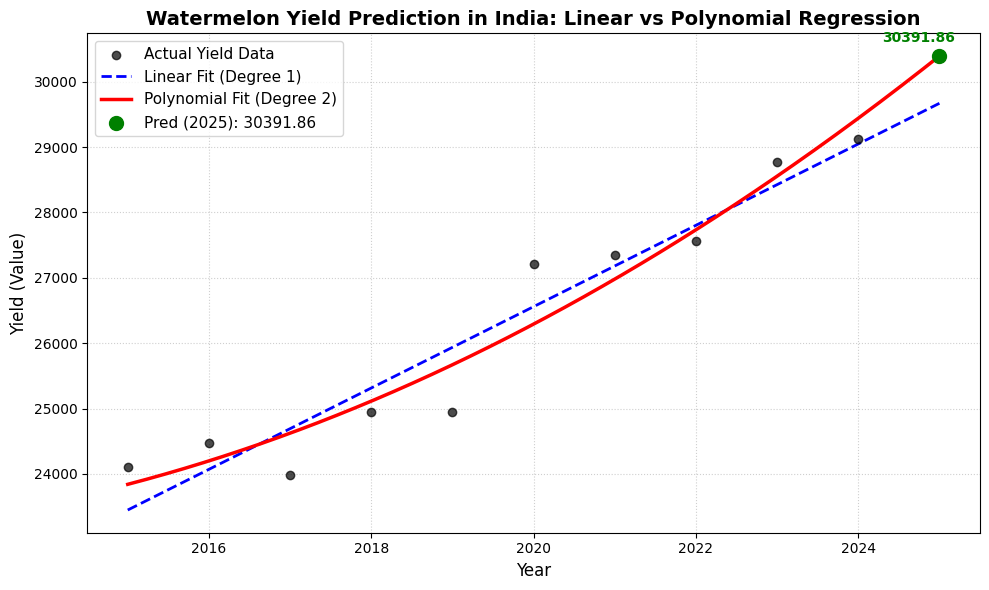

--- Actual vs Predicted Yield Comparison ---
 Year  Actual Yield  Linear Pred  Polynomial Pred
 2015       24101.1 23447.832728     23840.859980
 2016       24473.7 24069.938789     24199.016009
 2017       23978.0 24692.044849     24623.159483
 2018       24950.5 25314.150910     25113.290404
 2019       24950.0 25936.256970     25669.408771
 2020       27215.5 26558.363031     26291.514583
 2021       27344.5 27180.469092     26979.607842
 2022       27566.7 27802.575152     27733.688548
 2023       28777.8 28424.681213     28553.756699
 2024       29115.3 29046.787273     29439.812296

Predicted Yield for Year 2025 (Polynomial): 30391.86


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fits calculate karna
beta_poly1 = fit_polynomial_regression(X, Y, degree=1)
beta_poly2 = fit_polynomial_regression(X, Y, degree=2)

X_smooth = np.linspace(X.min(), X.max() + 1, 300) # +1 future predict point visualize karne ke liye
Y_smooth_poly1 = predict_poly(X_smooth, beta_poly1)
Y_smooth_poly2 = predict_poly(X_smooth, beta_poly2)

# 2. Next Year Prediction Point (e.g., Max Year + 1)
next_year = np.array([X.max() + 1])
pred_next_year = predict_poly(next_year, beta_poly2)[0]

# 3. Graph Plotting
plt.figure(figsize=(10, 6))

# Actual vs Fitted Points
plt.scatter(X, Y, color='black', alpha=0.7, label='Actual Yield Data', zorder=3)
plt.plot(X_smooth, Y_smooth_poly1, color='blue', linestyle='--', linewidth=2, label='Linear Fit (Degree 1)')
plt.plot(X_smooth, Y_smooth_poly2, color='red', linewidth=2.5, label='Polynomial Fit (Degree 2)')

# Highlight Predicted Point for Next Year
plt.scatter(next_year, pred_next_year, color='green', s=100, zorder=5, label=f'Pred ({next_year[0]}): {pred_next_year:.2f}')
plt.annotate(f'{pred_next_year:.2f}', (next_year[0], pred_next_year), textcoords="offset points", xytext=(-15,10), ha='center', fontweight='bold', color='green')

# Customization
plt.title('Watermelon Yield Prediction in India: Linear vs Polynomial Regression', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Yield (Value)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

# 4. Year-wise Prediction Table
results_df = pd.DataFrame({
    'Year': X,
    'Actual Yield': Y,
    'Linear Pred': predict_poly(X, beta_poly1),
    'Polynomial Pred': predict_poly(X, beta_poly2)
})

print("--- Actual vs Predicted Yield Comparison ---")
print(results_df.tail(10).to_string(index=False)) # Showing last 10 years
print(f"\nPredicted Yield for Year {next_year[0]} (Polynomial): {pred_next_year:.2f}")